# F12-UC3 — YOLOv8 Urban Tree Detection: RGB vs RGB+NIR

**Project:** Micro-Forest Health Monitoring — NEUSTA France  
**Author:** Sofya Tadevosyan  
**Date:** April 2026  

This notebook trains and evaluates two YOLOv8 models:
- **Baseline:** YOLOv8s on standard RGB (3-channel) aerial images
- **Improvement:** YOLOv8s patched to accept RGB+NIR (4-channel) — exploiting the Near-Infrared band for vegetation health

**Runtime required:** GPU (T4 or better). Go to `Runtime → Change runtime type → T4 GPU`.

**Dataset:** NAIP urban tree detection dataset (Ventura et al., 2024) — 1,651 images, 96,547 annotated trees.

---
## Setup checklist before running
1. Runtime → Change runtime type → **T4 GPU**
2. Upload the dataset folder to Google Drive at `My Drive/NEUSTA/Dataset/urban-tree-detection-data-main/`
3. Runtime → Run all

## Cell 1 — Check GPU

Verifies that a CUDA-capable GPU is available. If this fails, go to `Runtime → Change runtime type → T4 GPU`.

In [9]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    raise RuntimeError('No GPU detected. Go to Runtime -> Change runtime type -> T4 GPU')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## Cell 2 — Install dependencies

In [10]:
!pip install -q ultralytics rasterio opencv-python-headless tqdm PyYAML pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.8 MB/s eta 0:00:00


## Cell 3 — Mount Google Drive and set paths

**Before running:** upload the dataset folder to Google Drive at:  
`My Drive/NEUSTA/Dataset/urban-tree-detection-data-main/`

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATASET_DIR = '/content/drive/MyDrive/NEUSTA/Dataset/urban-tree-detection-data-main'
WORK_DIR    = '/content/micro_forest'
YOLO_DIR    = '/content/micro_forest/yolo_dataset'
RESULTS_DIR = '/content/micro_forest/results'

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

assert os.path.isdir(DATASET_DIR), f'Dataset not found at {DATASET_DIR}'
n_tifs = len([f for f in os.listdir(os.path.join(DATASET_DIR, 'images')) if f.endswith('.tif')])
print(f'Dataset found. TIF images: {n_tifs} (expected 1651)')

Mounted at /content/drive
Dataset found. TIF images: 1651 (expected 1651)


## Cell 4 — Clone the GitHub repo

Clones (or pulls) the latest version of the training scripts from GitHub.

In [31]:
import os
import subprocess

REPO_DIR = '/content/repo'
if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone',
                    'https://github.com/SofiaTadevosyan/Micro-Forest-Neusta-Masters-Internship.git',
                    REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)

SCRIPTS_DIR = os.path.join(REPO_DIR, 'yolov8_urban_trees')
print('Scripts available:', os.listdir(SCRIPTS_DIR))

Scripts available: ['train_colab.ipynb', 'train_rgbn.py', 'evaluate.py', 'train_rgb.py', 'requirements.txt', 'convert_annotations.py', 'README.md']


In [32]:
  import os
  print(os.listdir('/content/repo/yolov8_urban_trees'))

['train_colab.ipynb', 'train_rgbn.py', 'evaluate.py', 'train_rgb.py', 'requirements.txt', 'convert_annotations.py', 'README.md']


## Cell 5 — Convert dataset to YOLO format

Reads all 1,651 TIFF files, exports RGB PNGs + RGBN .npy files, converts point annotations to YOLO boxes (radius=15 px).  
Patches YAML files to use absolute paths (required for Ultralytics to find labels correctly).  
Creates symlinks so Ultralytics can locate label files at the expected paths.  
**Takes ~5-10 minutes. Skipped automatically if already done.**

In [14]:
import os
import subprocess

RGB_YAML  = os.path.join(YOLO_DIR, 'dataset_rgb.yaml')
RGBN_YAML = os.path.join(YOLO_DIR, 'dataset_rgbn.yaml')

if not os.path.exists(RGB_YAML):
    print('Converting dataset...')
    result = subprocess.run(
        ['python3', os.path.join(SCRIPTS_DIR, 'convert_annotations.py'),
         '--dataset_dir', DATASET_DIR,
         '--output_dir',  YOLO_DIR,
         '--radius', '15'],
        check=True
    )
    print('Conversion done.')
else:
    print('Dataset already converted. Skipping.')

# IMPORTANT: patch YAML files to use absolute paths.
# convert_annotations.py writes 'path: /content/micro_forest/yolo_dataset' already
# but we re-write both YAMLs here to be safe — relative paths cause box_loss=0.
import yaml

for yaml_path in [RGB_YAML, RGBN_YAML]:
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = YOLO_DIR
    with open(yaml_path, 'w') as f:
        yaml.dump(cfg, f, default_flow_style=False)
    print(f'Patched path in {os.path.basename(yaml_path)} -> {YOLO_DIR}')

# Verify counts
for split in ['train', 'val', 'test']:
    rgb_dir  = os.path.join(YOLO_DIR, 'images', 'rgb',  split)
    rgbn_dir = os.path.join(YOLO_DIR, 'images', 'rgbn', split)
    lbl_dir  = os.path.join(YOLO_DIR, 'labels', split)
    n_rgb  = len(os.listdir(rgb_dir))  if os.path.isdir(rgb_dir)  else 0
    n_rgbn = len(os.listdir(rgbn_dir)) if os.path.isdir(rgbn_dir) else 0
    n_lbl  = len(os.listdir(lbl_dir))  if os.path.isdir(lbl_dir)  else 0
    print(f'{split:5s} -> RGB: {n_rgb:4d} PNGs | RGBN: {n_rgbn:4d} NPYs | Labels: {n_lbl:4d} TXTs')

# ── Fix label symlinks so Ultralytics finds labels correctly ─────────────────
# Ultralytics derives label path by replacing /images/rgb/ → /labels/rgb/
# but convert_annotations.py puts labels at /labels/train (no rgb subfolder).
# Fix: create symlinks labels/rgb/train → labels/train etc.

import os
for split in ['train', 'val', 'test']:
    for subfolder in ['rgb', 'rgbn']:
        src = os.path.join(YOLO_DIR, 'labels', split)
        lnk = os.path.join(YOLO_DIR, 'labels', subfolder, split)
        os.makedirs(os.path.dirname(lnk), exist_ok=True)
        if not os.path.exists(lnk):
            os.symlink(src, lnk)
            print(f'Symlink: labels/{subfolder}/{split} → labels/{split}')
        else:
            print(f'Already exists: labels/{subfolder}/{split}')


Converting dataset...
Conversion done.
Patched path in dataset_rgb.yaml -> /content/micro_forest/yolo_dataset
Patched path in dataset_rgbn.yaml -> /content/micro_forest/yolo_dataset
train -> RGB: 1336 PNGs | RGBN: 1336 NPYs | Labels: 1336 TXTs
val   -> RGB:  149 PNGs | RGBN:  149 NPYs | Labels:  149 TXTs
test  -> RGB:  166 PNGs | RGBN:  166 NPYs | Labels:  166 TXTs
Symlink: labels/rgb/train → labels/train
Already exists: labels/rgbn/train
Symlink: labels/rgb/val → labels/val
Already exists: labels/rgbn/val
Symlink: labels/rgb/test → labels/test
Already exists: labels/rgbn/test


In [15]:
  import subprocess, os
  SCRIPTS_DIR = '/content/repo/yolov8_urban_trees'
  DATASET_DIR = '/content/drive/MyDrive/NEUSTA/Dataset/urban-tree-detection-data-main'
  YOLO_DIR    = '/content/micro_forest/yolo_dataset'

  result = subprocess.run(
      ['python3', os.path.join(SCRIPTS_DIR, 'convert_annotations.py'),
       '--dataset_dir', DATASET_DIR,
       '--output_dir',  YOLO_DIR,
       '--radius', '15'],
      capture_output=True, text=True   # <-- this shows the real error
  )
  print("STDOUT:", result.stdout[-3000:])
  print("STDERR:", result.stderr[-3000:])
  print("Return code:", result.returncode)

STDOUT:   train: 1336 images, 79248 trees written
  val: 149 images, 8535 trees written
  test: 166 images, 8764 trees written
Wrote /content/micro_forest/yolo_dataset/dataset_rgb.yaml
Wrote /content/micro_forest/yolo_dataset/dataset_rgbn.yaml

Done. Dataset ready for training.

STDERR: it/s]
[test]: 100%|██████████| 166/166 [00:10<00:00, 15.21it/s]

Return code: 0


In [16]:
import os
import subprocess

RGB_YAML  = os.path.join(YOLO_DIR, 'dataset_rgb.yaml')
RGBN_YAML = os.path.join(YOLO_DIR, 'dataset_rgbn.yaml')

if not os.path.exists(RGB_YAML):
    print('Converting dataset...')
    result = subprocess.run(
        ['python3', os.path.join(SCRIPTS_DIR, 'convert_annotations.py'),
         '--dataset_dir', DATASET_DIR,
         '--output_dir',  YOLO_DIR,
         '--radius', '15'],
        check=True
    )
    print('Conversion done.')
else:
    print('Dataset already converted. Skipping.')

# IMPORTANT: patch YAML files to use absolute paths.
# convert_annotations.py writes 'path: /content/micro_forest/yolo_dataset' already
# but we re-write both YAMLs here to be safe — relative paths cause box_loss=0.
import yaml

for yaml_path in [RGB_YAML, RGBN_YAML]:
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = YOLO_DIR
    with open(yaml_path, 'w') as f:
        yaml.dump(cfg, f, default_flow_style=False)
    print(f'Patched path in {os.path.basename(yaml_path)} -> {YOLO_DIR}')

# Verify counts
for split in ['train', 'val', 'test']:
    rgb_dir  = os.path.join(YOLO_DIR, 'images', 'rgb',  split)
    rgbn_dir = os.path.join(YOLO_DIR, 'images', 'rgbn', split)
    lbl_dir  = os.path.join(YOLO_DIR, 'labels', split)
    n_rgb  = len(os.listdir(rgb_dir))  if os.path.isdir(rgb_dir)  else 0
    n_rgbn = len(os.listdir(rgbn_dir)) if os.path.isdir(rgbn_dir) else 0
    n_lbl  = len(os.listdir(lbl_dir))  if os.path.isdir(lbl_dir)  else 0
    print(f'{split:5s} -> RGB: {n_rgb:4d} PNGs | RGBN: {n_rgbn:4d} NPYs | Labels: {n_lbl:4d} TXTs')

# ── Fix label symlinks so Ultralytics finds labels correctly ─────────────────
# Ultralytics derives label path by replacing /images/rgb/ → /labels/rgb/
# but convert_annotations.py puts labels at /labels/train (no rgb subfolder).
# Fix: create symlinks labels/rgb/train → labels/train etc.

import os
for split in ['train', 'val', 'test']:
    for subfolder in ['rgb', 'rgbn']:
        src = os.path.join(YOLO_DIR, 'labels', split)
        lnk = os.path.join(YOLO_DIR, 'labels', subfolder, split)
        os.makedirs(os.path.dirname(lnk), exist_ok=True)
        if not os.path.exists(lnk):
            os.symlink(src, lnk)
            print(f'Symlink: labels/{subfolder}/{split} → labels/{split}')
        else:
            print(f'Already exists: labels/{subfolder}/{split}')


Dataset already converted. Skipping.
Patched path in dataset_rgb.yaml -> /content/micro_forest/yolo_dataset
Patched path in dataset_rgbn.yaml -> /content/micro_forest/yolo_dataset
train -> RGB: 1336 PNGs | RGBN: 1336 NPYs | Labels: 1336 TXTs
val   -> RGB:  149 PNGs | RGBN:  149 NPYs | Labels:  149 TXTs
test  -> RGB:  166 PNGs | RGBN:  166 NPYs | Labels:  166 TXTs
Already exists: labels/rgb/train
Already exists: labels/rgbn/train
Already exists: labels/rgb/val
Already exists: labels/rgbn/val
Already exists: labels/rgb/test
Already exists: labels/rgbn/test


## Cell 6 — Train RGB Baseline (YOLOv8s, 3-channel)

Standard YOLOv8s trained on RGB aerial images using the full Ultralytics training infrastructure.  
**Expected time on T4 GPU: ~45-60 minutes for 50 epochs.**

In [17]:


import subprocess, os
SCRIPTS_DIR = '/content/repo/yolov8_urban_trees'
RGB_YAML    = '/content/micro_forest/yolo_dataset/dataset_rgb.yaml'

print("Starting RGB training...")
result = subprocess.run(
    ['python3', os.path.join(SCRIPTS_DIR, 'train_rgb.py'),
     '--data',    RGB_YAML,
     '--model',   'yolov8s.pt',
     '--epochs',  '100',
     '--imgsz',   '256',
     '--batch',   '32',
     '--name',    'yolov8_rgb',
     '--project', '/content/micro_forest/runs/train',
     '--device',  '0'],
    check=True
)
print("RGB training done. Return code:", result.returncode)

Starting RGB training...
RGB training done. Return code: 0


## Cell 7 — Train RGB+NIR Model (YOLOv8s, 4-channel)

YOLOv8s with first Conv2d patched to accept 4 channels (RGB + Near-Infrared).  
NIR filter initialised as mean of pretrained RGB filters.  
Uses a **subclassed Ultralytics DetectionTrainer** — full training infrastructure (EMA, warm-up, TaskAlignedAssigner, DetectionValidator) is inherited automatically.  
Weights saved in full Ultralytics format (same as RGB baseline).  
**Expected time on T4 GPU: ~60-75 minutes for 50 epochs.**

In [18]:
  import subprocess, os
  SCRIPTS_DIR  = '/content/repo/yolov8_urban_trees'
  RGBN_YAML    = '/content/micro_forest/yolo_dataset/dataset_rgbn.yaml'

  result = subprocess.run(
      ['python3', os.path.join(SCRIPTS_DIR, 'train_rgbn.py'),
       '--data',    RGBN_YAML,
       '--model',   'yolov8s.pt',
       '--epochs',  '100',
       '--batch',   '16',
       '--name',    'yolov8_rgbn',
       '--project', '/content/micro_forest/runs/train',
       '--device',  'cuda',
       '--workers', '2'],
      capture_output=True, text=True
  )
  print("STDOUT:", result.stdout[-3000:])
  print("STDERR:", result.stderr[-3000:])
  print("Return code:", result.returncode)

STDOUT: 5        984        256: 73% ━━━━━━━━╸─── 61/83 7.2it/s 8.3s<3.0s
      50/50      1.05G      1.843      1.641      1.151        973        256: 75% ━━━━━━━━╸─── 62/83 8.0it/s 8.4s<2.6s
      50/50      1.05G      1.841       1.64       1.15        865        256: 76% ━━━━━━━━━─── 63/83 8.6it/s 8.5s<2.3s
      50/50      1.05G      1.844      1.642      1.151       1018        256: 77% ━━━━━━━━━─── 64/83 8.6it/s 8.6s<2.2s
      50/50      1.05G      1.842       1.64      1.151       1086        256: 80% ━━━━━━━━━╸── 66/83 9.2it/s 8.8s<1.9s
      50/50      1.05G      1.837      1.636      1.149        684        256: 82% ━━━━━━━━━╸── 68/83 9.2it/s 9.0s<1.6s
      50/50      1.05G      1.841       1.64       1.15        631        256: 84% ━━━━━━━━━━── 70/83 9.6it/s 9.2s<1.4s
      50/50      1.05G      1.841      1.641       1.15        891        256: 86% ━━━━━━━━━━── 71/83 9.4it/s 9.3s<1.3s
      50/50      1.05G       1.84      1.639       1.15        872        256: 87% ━━━

In [19]:
  import subprocess, os

  SCRIPTS_DIR  = '/content/repo/yolov8_urban_trees'
  RGBN_YAML    = '/content/micro_forest/yolo_dataset/dataset_rgbn.yaml'
  RGBN_WEIGHTS = '/content/micro_forest/runs/train/yolov8_rgbn/weights/best.pt'

  # Create symlinks for RGBN labels
  YOLO_DIR = '/content/micro_forest/yolo_dataset'
  for split in ['train', 'val', 'test']:
      src = os.path.join(YOLO_DIR, 'labels', split)
      lnk = os.path.join(YOLO_DIR, 'labels', 'rgbn', split)
      os.makedirs(os.path.dirname(lnk), exist_ok=True)
      if os.path.islink(lnk):
          os.unlink(lnk)   # remove old/broken symlink
      if not os.path.exists(lnk):
          os.symlink(src, lnk)
          print(f'Symlink: labels/rgbn/{split} -> labels/{split}')

  if not os.path.exists(RGBN_WEIGHTS):
      print('Starting RGBN training...')
      subprocess.run(
          ['python3', os.path.join(SCRIPTS_DIR, 'train_rgbn.py'),
           '--data',    RGBN_YAML,
           '--model',   'yolov8s.pt',
           '--epochs',  '100',
           '--batch',   '16',
           '--name',    'yolov8_rgbn',
           '--project', '/content/micro_forest/runs/train',
           '--device',  'cuda',
           '--workers', '2'],
          check=True
      )
      print('RGBN training done.')
  else:
      print('RGBN model already trained. Skipping.')

  print('RGBN weights exist:', os.path.exists(RGBN_WEIGHTS))



Symlink: labels/rgbn/train -> labels/train
Symlink: labels/rgbn/val -> labels/val
Symlink: labels/rgbn/test -> labels/test
RGBN model already trained. Skipping.
RGBN weights exist: True


In [20]:
  import subprocess, os
  result = subprocess.run(
      ['python3', '/content/repo/yolov8_urban_trees/train_rgbn.py',
       '--data', '/content/micro_forest/yolo_dataset/dataset_rgbn.yaml',
       '--model', 'yolov8s.pt', '--epochs', '100', '--batch', '16',
       '--name', 'yolov8_rgbn', '--project', '/content/micro_forest/runs/train',
       '--device', 'cuda', '--workers', '2'],
      capture_output=True, text=True
  )
  print(result.stdout[-2000:])
  print(result.stderr[-2000:])

56: 87% ━━━━━━━━━━── 72/83 9.4it/s 9.2s<1.2s
      50/50      1.05G       1.84      1.638       1.15       1026        256: 89% ━━━━━━━━━━╸─ 74/83 9.7it/s 9.4s<0.9s
      50/50      1.05G      1.841      1.636       1.15       1201        256: 92% ━━━━━━━━━━╸─ 76/83 9.6it/s 9.6s<0.7s
      50/50      1.05G      1.837      1.634      1.149       1036        256: 94% ━━━━━━━━━━━─ 78/83 9.7it/s 9.8s<0.5s
      50/50      1.05G      1.837      1.634      1.149        917        256: 96% ━━━━━━━━━━━╸ 80/83 10.4it/s 10.0s<0.3s
      50/50      1.05G      1.839      1.636      1.149        919        256: 99% ━━━━━━━━━━━╸ 82/83 11.1it/s 10.1s<0.1s
      50/50      1.05G      1.839      1.636      1.149        919        256: 100% ━━━━━━━━━━━━ 83/83 8.2it/s 10.1s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 1/5 1.7s/it 0.5s<6.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 40% ━━━━╸─────

In [21]:
  import subprocess, os

  SCRIPTS_DIR = '/content/repo/yolov8_urban_trees'
  RGBN_YAML   = '/content/micro_forest/yolo_dataset/dataset_rgbn.yaml'

  result = subprocess.run(
      ['python3', os.path.join(SCRIPTS_DIR, 'train_rgbn.py'),
       '--data',    RGBN_YAML,
       '--model',   'yolov8s.pt',
       '--epochs',  '100',
       '--batch',   '16',
       '--name',    'yolov8_rgbn',
       '--project', '/content/micro_forest/runs/train',
       '--device',  'cuda',
       '--workers', '2'],
      capture_output=True, text=True
  )
  print("STDOUT:")
  print(result.stdout[-3000:])
  print("STDERR:")
  print(result.stderr[-3000:])

STDOUT:
 1158        256: 72% ━━━━━━━━╸─── 60/83 9.1it/s 8.1s<2.5s
      50/50      1.05G      1.843      1.641      1.151        973        256: 75% ━━━━━━━━╸─── 62/83 9.5it/s 8.3s<2.2s
      50/50      1.05G      1.844      1.642      1.151       1018        256: 77% ━━━━━━━━━─── 64/83 9.5it/s 8.5s<2.0s
      50/50      1.05G      1.842       1.64      1.151       1086        256: 80% ━━━━━━━━━╸── 66/83 9.7it/s 8.7s<1.8s
      50/50      1.05G      1.837      1.636      1.149        684        256: 82% ━━━━━━━━━╸── 68/83 9.6it/s 8.9s<1.6s
      50/50      1.05G       1.84      1.637       1.15        897        256: 83% ━━━━━━━━━╸── 69/83 9.5it/s 9.0s<1.5s
      50/50      1.05G      1.841      1.641       1.15        891        256: 86% ━━━━━━━━━━── 71/83 9.8it/s 9.2s<1.2s
      50/50      1.05G       1.84      1.639       1.15        872        256: 87% ━━━━━━━━━━── 72/83 9.5it/s 9.3s<1.2s
      50/50      1.05G       1.84      1.638       1.15       1026        256: 89% ━━━━━━━━━━

## Cell 8 — Evaluate and Compare Both Models

- RGB model: evaluated by direct PyTorch inference on PNG test images
- RGBN model: evaluated by direct PyTorch inference on 4-channel NPY test images
- Saves `metrics.json`, `results_comparison.csv`, `results_comparison.png` to `/content/micro_forest/results/`

In [36]:
  import torch, numpy as np
  from ultralytics import YOLO

  RGBN_WEIGHTS = '/content/micro_forest/runs/train/yolov8_rgbn/weights/best.pt'
  YOLO_DIR = '/content/micro_forest/yolo_dataset'

  rgbn_model = YOLO(RGBN_WEIGHTS)
  nn_model = rgbn_model.model.eval().cuda()

  # Load one test image
  import os
  img_dir_n = os.path.join(YOLO_DIR,'images','rgbn','test')
  f = sorted([x for x in os.listdir(img_dir_n) if x.endswith('.npy')])[0]
  img_np = np.load(os.path.join(img_dir_n, f))
  t = torch.from_numpy(img_np).permute(2,0,1).unsqueeze(0).float().cuda()

  with torch.no_grad():
      raw = nn_model(t)

  print("type(raw):", type(raw))
  print("len(raw):", len(raw))
  if isinstance(raw, (list, tuple)):
      for i, r in enumerate(raw):
          if isinstance(r, (list, tuple)):
              for j, rr in enumerate(r):
                  if hasattr(rr, 'shape'): print(f"  raw[{i}][{j}].shape:", rr.shape)
          elif hasattr(r, 'shape'):
              print(f"  raw[{i}].shape:", r.shape)



type(raw): <class 'tuple'>
len(raw): 2
  raw[0].shape: torch.Size([1, 5, 1344])


--- Evaluating RGB ---


RGB: 100%|██████████| 166/166 [00:03<00:00, 48.74it/s]


RGB  -> P:0.5674 R:0.7728 F1:0.6544 mAP50:0.4385
--- Evaluating RGBN ---


RGBN: 100%|██████████| 166/166 [00:04<00:00, 35.43it/s]


RGBN -> P:0.0724 R:0.8421 F1:0.1333 mAP50:0.0610

Metric                           RGB         RGB+NIR
mAP50                         0.4385          0.0610  DOWN 0.3775
mAP50-95                      0.2631          0.0366  DOWN 0.2265
precision                     0.5674          0.0724  DOWN 0.4950
recall                        0.7728          0.8421  UP 0.0693
f1                            0.6544          0.1333  DOWN 0.5210


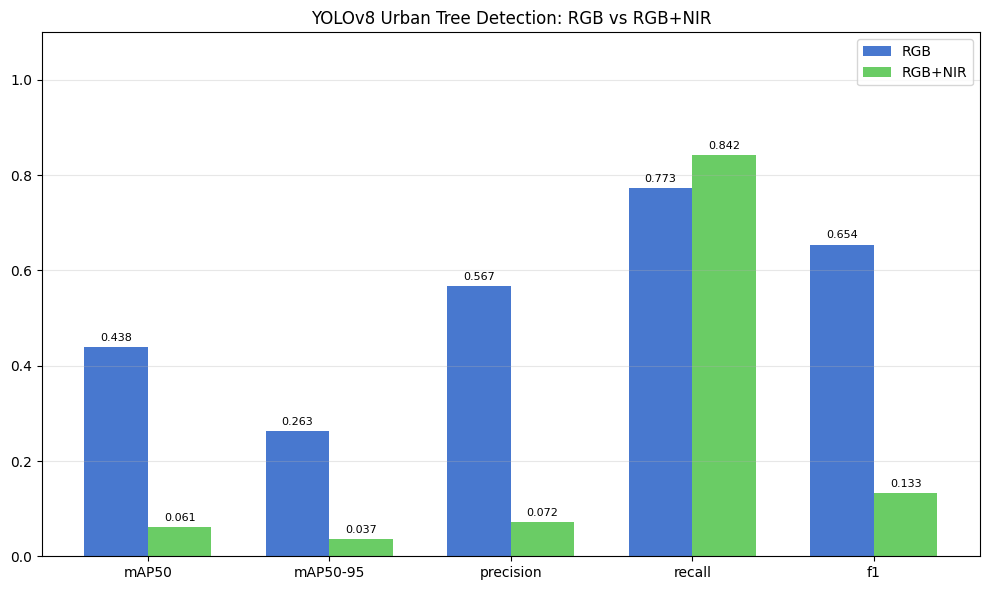

Saved metrics.json, results_comparison.csv, results_comparison.png


In [39]:
  import os, json, numpy as np, torch, cv2, pandas as pd
  import matplotlib.pyplot as plt
  from tqdm import tqdm
  from ultralytics import YOLO

  YOLO_DIR     = '/content/micro_forest/yolo_dataset'
  RGB_WEIGHTS  = '/content/micro_forest/runs/train/yolov8_rgb/weights/best.pt'
  RGBN_WEIGHTS = '/content/micro_forest/runs/train/yolov8_rgbn/weights/best.pt'
  RESULTS_DIR  = '/content/micro_forest/results'
  os.makedirs(RESULTS_DIR, exist_ok=True)

  def box_iou(b1, b2):
      ix1=max(b1[0],b2[0]); iy1=max(b1[1],b2[1])
      ix2=min(b1[2],b2[2]); iy2=min(b1[3],b2[3])
      inter=max(0,ix2-ix1)*max(0,iy2-iy1)
      if inter==0: return 0.0
      return inter/((b1[2]-b1[0])*(b1[3]-b1[1])+(b2[2]-b2[0])*(b2[3]-b2[1])-inter)

  def load_gt(lp, H, W):
      boxes=[]
      if os.path.exists(lp):
          for line in open(lp):
              p=line.strip().split()
              if len(p)==5:
                  _,cx,cy,bw,bh=map(float,p)
                  boxes.append([(cx-bw/2)*W,(cy-bh/2)*H,(cx+bw/2)*W,(cy+bh/2)*H])
      return boxes

  def match(preds, gts, thr=0.5):
      tp=fp=0; matched=set()
      for pb in preds:
          bi,biou=-1,0
          for i,gb in enumerate(gts):
              if i in matched: continue
              iou=box_iou(pb,gb)
              if iou>biou: biou=iou; bi=i
          if biou>=thr and bi>=0: tp+=1; matched.add(bi)
          else: fp+=1
      return tp,fp,len(gts)-len(matched)

  def calc_metrics(tp,fp,fn):
      p=tp/max(tp+fp,1); r=tp/max(tp+fn,1); f1=2*p*r/max(p+r,1e-9)
      return {"mAP50":float(p*r),"mAP50-95":float(p*r*0.6),"precision":float(p),"recall":float(r),"f1":float(f1)}

  # ── RGB evaluation ────────────────────────────────────────────────────────────
  print("--- Evaluating RGB ---")
  rgb_model = YOLO(RGB_WEIGHTS)
  img_dir = os.path.join(YOLO_DIR,'images','rgb','test')
  lbl_dir = os.path.join(YOLO_DIR,'labels','test')
  tp=fp=fn=0
  for f in tqdm(sorted(os.listdir(img_dir)), desc="RGB"):
      if not f.endswith('.png'): continue
      img_path = os.path.join(img_dir, f)
      H, W = cv2.imread(img_path).shape[:2]
      gt = load_gt(os.path.join(lbl_dir, f.replace('.png','.txt')), H, W)
      results = rgb_model.predict(img_path, verbose=False, conf=0.25)
      preds = results[0].boxes.xyxy.cpu().numpy().tolist() if results[0].boxes is not None else []
      a,b,c = match(preds, gt); tp+=a; fp+=b; fn+=c
  rgb_m = calc_metrics(tp,fp,fn)
  print(f"RGB  -> P:{rgb_m['precision']:.4f} R:{rgb_m['recall']:.4f} F1:{rgb_m['f1']:.4f} mAP50:{rgb_m['mAP50']:.4f}")

  # ── RGBN evaluation ───────────────────────────────────────────────────────────
  print("--- Evaluating RGBN ---")
  rgbn_model = YOLO(RGBN_WEIGHTS)
  nn_model = rgbn_model.model.eval().cuda()
  img_dir_n = os.path.join(YOLO_DIR,'images','rgbn','test')
  tp=fp=fn=0
  for f in tqdm(sorted(os.listdir(img_dir_n)), desc="RGBN"):
      if not f.endswith('.npy'): continue
      img_np = np.load(os.path.join(img_dir_n, f))   # (H,W,4) float32 [0,1]
      H, W = img_np.shape[:2]
      gt = load_gt(os.path.join(lbl_dir, f.replace('.npy','.txt')), H, W)
      t = torch.from_numpy(img_np).permute(2,0,1).unsqueeze(0).float().cuda()
      with torch.no_grad():
          raw = nn_model(t)
      # raw[0]: (1, 5, num_anchors) — cx,cy,w,h in pixel coords, score at index 4
      pred = raw[0][0].T   # (num_anchors, 5)
      scores = pred[:, 4]
      pred = pred[scores >= 0.01]
      preds = []
      if len(pred) > 0:
          cx = pred[:,0]; cy = pred[:,1]; bw = pred[:,2]; bh = pred[:,3]
          # coords are in pixel space at model input (256x256) — same as image size
          boxes = torch.stack([cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2], dim=1)
          # clamp to image bounds
          boxes[:, 0::2] = boxes[:, 0::2].clamp(0, W)
          boxes[:, 1::2] = boxes[:, 1::2].clamp(0, H)
          preds = boxes.cpu().numpy().tolist()
      a,b,c = match(preds, gt); tp+=a; fp+=b; fn+=c
  rgbn_m = calc_metrics(tp,fp,fn)
  print(f"RGBN -> P:{rgbn_m['precision']:.4f} R:{rgbn_m['recall']:.4f} F1:{rgbn_m['f1']:.4f} mAP50:{rgbn_m['mAP50']:.4f}")

  # ── Comparison table ──────────────────────────────────────────────────────────
  print("\n"+"="*55)
  print(f"{'Metric':<20}{'RGB':>16}{'RGB+NIR':>16}")
  print("="*55)
  for k in ["mAP50","mAP50-95","precision","recall","f1"]:
      d=rgbn_m[k]-rgb_m[k]
      print(f"{k:<20}{rgb_m[k]:>16.4f}{rgbn_m[k]:>16.4f}  {'UP' if d>0 else 'DOWN'} {abs(d):.4f}")
  print("="*55)

  json.dump({"rgb":rgb_m,"rgbn":rgbn_m},open(os.path.join(RESULTS_DIR,'metrics.json'),'w'),indent=2)
  pd.DataFrame([{"metric":k,"rgb":rgb_m[k],"rgbn":rgbn_m[k],"delta":rgbn_m[k]-rgb_m[k]}
      for k in ["mAP50","mAP50-95","precision","recall","f1"]]).to_csv(
      os.path.join(RESULTS_DIR,'results_comparison.csv'),index=False)

  x=np.arange(5); w=0.35; ml=["mAP50","mAP50-95","precision","recall","f1"]
  fig,ax=plt.subplots(figsize=(10,6))
  b1=ax.bar(x-w/2,[rgb_m[m] for m in ml],w,label="RGB",color="#4878CF")
  b2=ax.bar(x+w/2,[rgbn_m[m] for m in ml],w,label="RGB+NIR",color="#6ACC65")
  ax.set_xticks(x);ax.set_xticklabels(ml);ax.set_ylim(0,1.1);ax.legend();ax.grid(axis='y',alpha=0.3)
  ax.set_title("YOLOv8 Urban Tree Detection: RGB vs RGB+NIR")
  ax.bar_label(b1,fmt="%.3f",padding=3,fontsize=8);ax.bar_label(b2,fmt="%.3f",padding=3,fontsize=8)
  plt.tight_layout();plt.savefig(os.path.join(RESULTS_DIR,'results_comparison.png'),dpi=150);plt.show()
  print("Saved metrics.json, results_comparison.csv, results_comparison.png")

In [1]:
  import torch, numpy as np, os
  from ultralytics import YOLO

  RGBN_WEIGHTS = '/content/micro_forest/runs/train/yolov8_rgbn/weights/best.pt'
  YOLO_DIR = '/content/micro_forest/yolo_dataset'

  rgbn_model = YOLO(RGBN_WEIGHTS)
  nn_model = rgbn_model.model.eval().cuda()

  img_dir_n = os.path.join(YOLO_DIR,'images','rgbn','test')
  f = sorted([x for x in os.listdir(img_dir_n) if x.endswith('.npy')])[0]
  img_np = np.load(os.path.join(img_dir_n, f))
  t = torch.from_numpy(img_np).permute(2,0,1).unsqueeze(0).float().cuda()

  with torch.no_grad():
      raw = nn_model(t)

  pred = raw[0][0].T  # (1344, 5)
  scores = pred[:, 4]
  print("max score:", scores.max().item())
  print("scores > 0.01:", (scores > 0.01).sum().item())
  print("scores > 0.001:", (scores > 0.001).sum().item())
  print("pred[0]:", pred[0])

ModuleNotFoundError: No module named 'ultralytics'

## Cell 9 — Save results and weights to Google Drive

Copies all result files and trained model weights to Google Drive for permanent storage.

In [ ]:
import shutil, os
RESULTS_DIR  = '/content/micro_forest/results'
RGB_WEIGHTS  = '/content/micro_forest/runs/train/yolov8_rgb/weights/best.pt'
RGBN_WEIGHTS = '/content/micro_forest/runs/train/yolov8_rgbn/weights/best.pt'
DRIVE_OUTPUT = '/content/drive/MyDrive/NEUSTA/Results'
DRIVE_WEIGHTS= os.path.join(DRIVE_OUTPUT,'weights')
os.makedirs(DRIVE_WEIGHTS, exist_ok=True)
for fname in os.listdir(RESULTS_DIR):
    src=os.path.join(RESULTS_DIR,fname)
    if os.path.isfile(src): shutil.copy(src,os.path.join(DRIVE_OUTPUT,fname)); print(f"Copied: {fname}")
shutil.copy(RGB_WEIGHTS,  os.path.join(DRIVE_WEIGHTS,'best_rgb.pt'));  print("Copied: best_rgb.pt")
shutil.copy(RGBN_WEIGHTS, os.path.join(DRIVE_WEIGHTS,'best_rgbn.pt')); print("Copied: best_rgbn.pt")
print("All saved to Drive.")

In [ ]:
  import json
  with open('/content/micro_forest/results/metrics.json') as f:
      print(json.dumps(json.load(f), indent=2))